In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
file_path = '/content/drive/MyDrive/dati/bindprofx'
try:
    df_drive = pd.read_csv(file_path, sep = " ")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
df_drive

,Protein,Mutation(s)_cleaned,Location(s),Affinity_mut,(M),Affinity_wt,(M).1,ddG
0,1CSE_E_I,LI38G,COR,5.260000e-11,1.120000e-12,2.280577,NaN,NaN
1,1CSE_E_I,LI38S,COR,8.330000e-12,1.120000e-12,1.188776,NaN,NaN
2,1CSE_E_I,LI38P,COR,1.020000e-07,1.120000e-12,6.765446,NaN,NaN
3,1CSE_E_I,LI38I,COR,1.720000e-10,1.120000e-12,2.982502,NaN,NaN
4,1CSE_E_I,LI38D,COR,1.920000e-09,1.120000e-12,4.411843,NaN,NaN
...,...,...,...,...,...,...,...,...
3042,1PPF_E_I,TI17A,COR,2.170000e-08,1.640000e-10,2.894247,NaN,NaN
3043,1PPF_E_I,LI18K,COR,2.270000e-06,1.640000e-10,5.649281,NaN,NaN
3044,1PPF_E_I,LI18A,COR,8.330000e-10,1.640000e-10,0.962834,NaN,NaN
3045,1PPF_E_I,LI18E,COR,2.500000e-05,1.640000e-10,7.070630,NaN,NaN


In [10]:
ids = df_drive["Protein"].to_list()
i = 0
for i in range(len(ids)):
  ids[i] = ids[i].split('_')[0]
df_drive['PDB'] = ids
df_drive.head()

,Protein,Mutation(s)_cleaned,Location(s),Affinity_mut,(M),Affinity_wt,(M).1,ddG,PDB
0,1CSE_E_I,LI38G,COR,5.260000e-11,1.120000e-12,2.280577,NaN,NaN,1CSE
1,1CSE_E_I,LI38S,COR,8.330000e-12,1.120000e-12,1.188776,NaN,NaN,1CSE
2,1CSE_E_I,LI38P,COR,1.020000e-07,1.120000e-12,6.765446,NaN,NaN,1CSE
3,1CSE_E_I,LI38I,COR,1.720000e-10,1.120000e-12,2.982502,NaN,NaN,1CSE
4,1CSE_E_I,LI38D,COR,1.920000e-09,1.120000e-12,4.411843,NaN,NaN,1CSE


In [11]:
pdb_occurrences = df_drive['PDB'].value_counts().to_dict()
print(pdb_occurrences)
print(len(pdb_occurrences))

{'1CHO': 291, '3SGB': 291, '1R0R': 280, '1PPF': 255, '1A22': 193, '1JTG': 174, '1DAN': 130, '3HFM': 111, '1BRS': 94, '1JRH': 74, '1EMV': 59, '1GC1': 56, '2WPT': 53, '1VFB': 50, '1DVF': 46, '1A4Y': 45, '2JEL': 43, '1DQJ': 39, '2G2U': 36, '1IAR': 36, '1CBW': 32, '1EAW': 27, '3NPS': 27, '1KTZ': 27, '1TM1': 26, '1REW': 26, '3BN9': 25, '1LFD': 25, '2J0T': 22, '1Z7X': 21, '2FTL': 20, '1XD3': 18, '1FFW': 17, '1AK4': 15, '2VLJ': 14, '1FC2': 14, '1MAH': 13, '3BK3': 13, '2PCC': 12, '1F47': 12, '1AHW': 11, '2SIC': 10, '1HE8': 10, '1FCC': 8, '1NMB': 8, '2O3B': 8, '4CPA': 8, '1JCK': 7, '1GCQ': 7, '1MQ8': 7, '1S1Q': 6, '2PCB': 6, '1CSE': 6, '1ACB': 6, '1E96': 6, '1H9D': 6, '2I9B': 5, '1UUZ': 5, '2AJF': 4, '2BTF': 4, '1NCA': 4, '2GOX': 4, '1SMF': 4, '2OOB': 4, '2J1K': 3, '1N8O': 3, '1B2S': 3, '1B2U': 3, '1B3S': 3, '1SBB': 3, '2QJA': 3, '2C0L': 3, '2HRK': 3, '3BP8': 3, '2QJB': 3, '2QJ9': 3, '1EFN': 3, '2B42': 3, '1GL0': 2, '1KAC': 2, '2HLE': 2, '1FY8': 2, '2VIR': 2, '3D5R': 2, '3D5S': 2, '2I26': 2, '1

In [12]:
with open("pdb_bindprofx.txt", "w") as writer:
  for key in pdb_occurrences:
    writer.write(key+"\n")

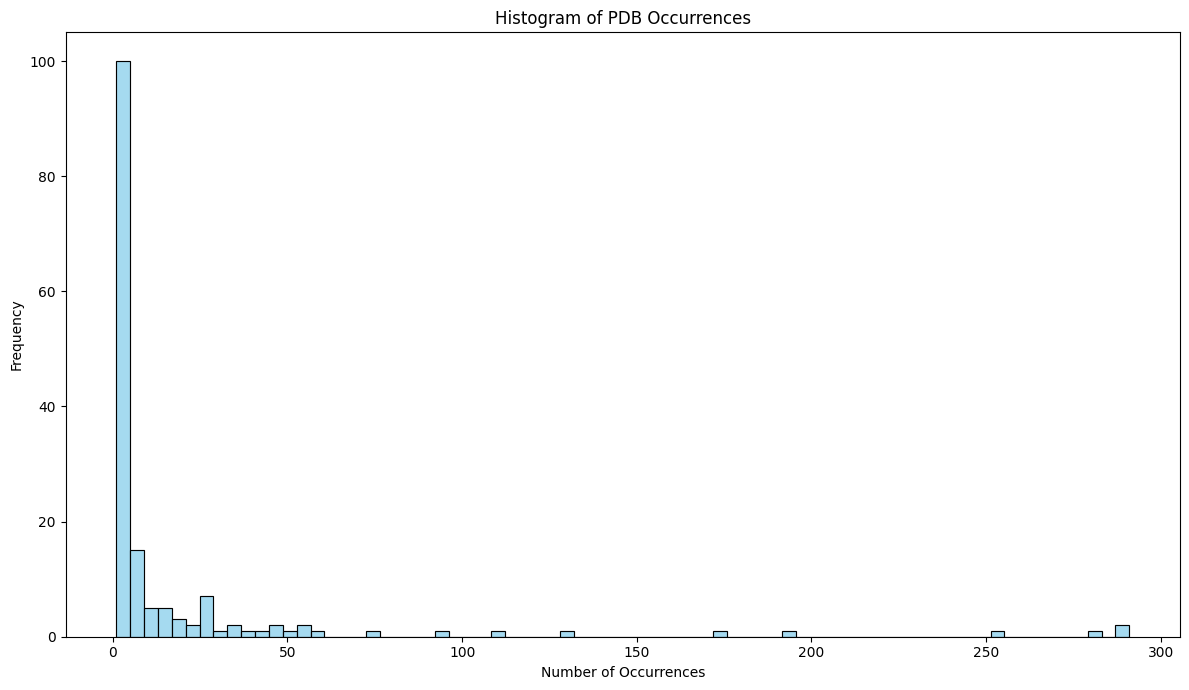

In [13]:
pdb_counts_series = pd.Series(pdb_occurrences)

plt.figure(figsize=(12, 7))
sns.histplot(pdb_counts_series.values, fill=True, color='skyblue', kde=False)
plt.title('Histogram of PDB Occurrences')
plt.xlabel('Number of Occurrences')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [14]:
filepath = '/content/drive/MyDrive/dati/bindprofx_mapping.tsv'
try:
    df_mapping = pd.read_table(filepath)
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [15]:
df_mapping.head()

,From,Entry,Entry Name
0,1CHO,P68390,IOVO_MELGA
1,1CHO,P00766,CTRA_BOVIN
2,3SGB,P00777,PRTB_STRGR
3,3SGB,P68390,IOVO_MELGA
4,1R0R,P00780,SUBC_BACLI


In [16]:
from_entry_dict = df_mapping.groupby('From')['Entry'].apply(list).to_dict()
print(from_entry_dict)

{'1A22': ['P01241', 'P10912'], '1A4Y': ['P03950', 'P13489'], '1ACB': ['P01051', 'P00766'], '1AHW': ['P01837', 'P01868', 'P13726'], '1AK4': ['P12497', 'P62937'], '1B2S': ['P00648', 'P11540'], '1B2U': ['P00648', 'P11540'], '1B3S': ['P00648', 'P11540'], '1BRS': ['P00648', 'P11540'], '1CBW': ['P00766', 'P00767', 'P00974'], '1CHO': ['P68390', 'P00766'], '1CSE': ['P00780', 'P01051'], '1CSO': ['P00777', 'P68390'], '1CT0': ['P00777', 'P68390'], '1CT2': ['P00777', 'P68390'], '1CT4': ['P00777', 'P68390'], '1DAN': ['P08709', 'P13726'], '1DQJ': ['P01837', 'P01865', 'P00698'], '1DVF': ['P01635', 'P01646', 'P01820'], '1E96': ['P19878', 'P63000'], '1EAW': ['Q9Y5Y6', 'P00974'], '1EFN': ['P03406', 'P06241'], '1EMV': ['P09883', 'P13479'], '1F47': ['P0A9A6', 'P77173'], '1F5R': ['P00763', 'P00974'], '1FC2': ['P38507', 'P01857'], '1FCC': ['P19909', 'P01857'], '1FFW': ['P07363', 'P0AE67'], '1FR2': ['P09883', 'P13479'], '1FY8': ['P00763', 'P00974'], '1GC1': ['P04578', 'P01730'], '1GCQ': ['P27870', 'P62993'],

In [17]:
df_drive['uniprot'] = df_drive['PDB'].map(from_entry_dict)
display(df_drive.head())

,Protein,Mutation(s)_cleaned,Location(s),Affinity_mut,(M),Affinity_wt,(M).1,ddG,PDB,uniprot
0,1CSE_E_I,LI38G,COR,5.260000e-11,1.120000e-12,2.280577,NaN,NaN,1CSE,"[P00780, P01051]"
1,1CSE_E_I,LI38S,COR,8.330000e-12,1.120000e-12,1.188776,NaN,NaN,1CSE,"[P00780, P01051]"
2,1CSE_E_I,LI38P,COR,1.020000e-07,1.120000e-12,6.765446,NaN,NaN,1CSE,"[P00780, P01051]"
3,1CSE_E_I,LI38I,COR,1.720000e-10,1.120000e-12,2.982502,NaN,NaN,1CSE,"[P00780, P01051]"
4,1CSE_E_I,LI38D,COR,1.920000e-09,1.120000e-12,4.411843,NaN,NaN,1CSE,"[P00780, P01051]"


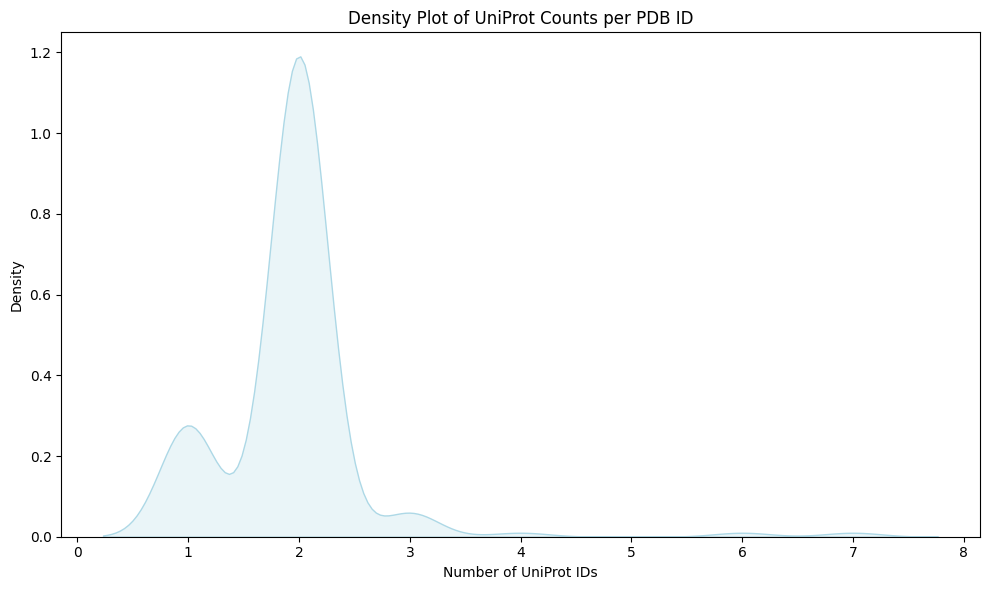

In [18]:
proteins_compl = {}
for key in from_entry_dict:
  proteins_compl[key]=len(from_entry_dict[key])

uniprot_counts_series = pd.Series(proteins_compl)

plt.figure(figsize=(10, 6))
sns.kdeplot(uniprot_counts_series.values, fill=True, color='lightblue')
plt.title('Density Plot of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

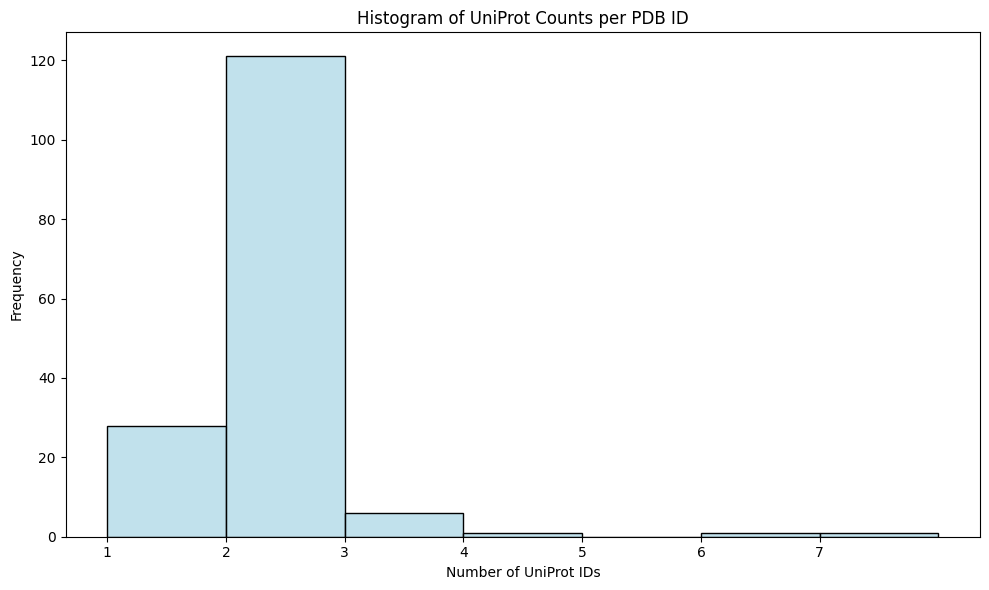

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(uniprot_counts_series.values, bins=range(1, max(uniprot_counts_series.values) + 2), kde=False, color='lightblue', edgecolor='black')
plt.title('Histogram of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Frequency')
plt.xticks(range(1, max(uniprot_counts_series.values) + 1))
plt.tight_layout()
plt.show()

In [20]:
min_uniprot_count = min(proteins_compl.values())
print(f"The minimum number of UniProt IDs associated with a PDB ID is: {min_uniprot_count}")

The minimum number of UniProt IDs associated with a PDB ID is: 1


In [21]:
max_uniprot_count = max(proteins_compl.values())
print(f"The maximum number of UniProt IDs associated with a PDB ID is: {max_uniprot_count}")

The maximum number of UniProt IDs associated with a PDB ID is: 7


In [22]:
prot_per_complex = {}

In [23]:
pdb_1_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 1]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_1_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_1_uniprot:
    print(pdb_id)
prot_per_complex[1]=len(pdb_1_uniprot)

Number of PDB IDs with exactly one UniProt ID: 28
PDB IDs with exactly one UniProt ID:
1JCK
1M9E
1NMB
1TM1
1TM3
1TM4
1TM5
1TM7
1TMG
1TO1
1Y1K
1Y33
1Y34
1Y3B
1Y3C
1Y3D
1Y48
1Y4A
2B42
2I26
2J12
2JEL
2NOJ
2O3B
2VIR
2VIS
3BK3
3NPS


In [24]:
pdb_2_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 2]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_2_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_2_uniprot:
    print(pdb_id)
prot_per_complex[2]=len(pdb_2_uniprot)

Number of PDB IDs with exactly one UniProt ID: 121
PDB IDs with exactly one UniProt ID:
1A22
1A4Y
1ACB
1AK4
1B2S
1B2U
1B3S
1BRS
1CHO
1CSE
1CSO
1CT0
1CT2
1CT4
1DAN
1E96
1EAW
1EFN
1EMV
1F47
1F5R
1FC2
1FCC
1FFW
1FR2
1FY8
1GC1
1GCQ
1GL0
1GL1
1GRN
1H9D
1HE8
1IAR
1JTG
1KAC
1KIP
1KIQ
1KIR
1KTZ
1LFD
1MAH
1MQ8
1N8O
1NCA
1P69
1P6A
1PPF
1R0R
1REW
1S0W
1S1Q
1SBB
1SBN
1SGD
1SGE
1SGN
1SGP
1SGQ
1SGY
1SIB
1SMF
1UUZ
1X1W
1X1X
1XD3
1XXM
1Z7X
2A9K
2ABZ
2AJF
2B0Z
2B10
2B11
2B12
2BTF
2C0L
2FTL
2G2U
2G2W
2GOX
2GYK
2HLE
2HRK
2I9B
2J0T
2J1K
2NU0
2NU1
2NU2
2NU4
2OOB
2PCB
2PCC
2QJ9
2QJA
2QJB
2SGP
2SGQ
2SIC
2VLN
2VLO
2VLP
2VLQ
2WPT
3BP8
3BTD
3BTE
3BTF
3BTG
3BTH
3BTM
3BTQ
3BTT
3BTW
3D5R
3D5S
3HFM
3SGB
3TGK
4CPA


In [25]:
pdb_3_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 3]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_3_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_3_uniprot:
    print(pdb_id)
prot_per_complex[3]=len(pdb_3_uniprot)

Number of PDB IDs with exactly one UniProt ID: 6
PDB IDs with exactly one UniProt ID:
1AHW
1CBW
1DQJ
1DVF
1JRH
1VFB


In [26]:
pdb_4_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 4]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_4_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_4_uniprot:
    print(pdb_id)
prot_per_complex[4]=len(pdb_4_uniprot)

Number of PDB IDs with exactly one UniProt ID: 1
PDB IDs with exactly one UniProt ID:
3BN9


In [27]:
pdb_5_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 5]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_5_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_5_uniprot:
    print(pdb_id)
prot_per_complex[5]=len(pdb_5_uniprot)

Number of PDB IDs with exactly one UniProt ID: 0
PDB IDs with exactly one UniProt ID:


In [28]:
pdb_6_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 6]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_6_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_6_uniprot:
    print(pdb_id)
prot_per_complex[6]=len(pdb_6_uniprot)

Number of PDB IDs with exactly one UniProt ID: 1
PDB IDs with exactly one UniProt ID:
2VLJ


In [29]:
pdb_7_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 7]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_7_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_7_uniprot:
    print(pdb_id)
prot_per_complex[7]=len(pdb_7_uniprot)

Number of PDB IDs with exactly one UniProt ID: 1
PDB IDs with exactly one UniProt ID:
2VLR


In [30]:
for key in prot_per_complex:
  print("The complexes with " + str(key)+ " uniprot ID are: " + str(prot_per_complex[key]))

The complexes with 1 uniprot ID are: 28
The complexes with 2 uniprot ID are: 121
The complexes with 3 uniprot ID are: 6
The complexes with 4 uniprot ID are: 1
The complexes with 5 uniprot ID are: 0
The complexes with 6 uniprot ID are: 1
The complexes with 7 uniprot ID are: 1


In [31]:
print("The dataset counts a total of: "+str(prot_per_complex[1]*1+prot_per_complex[2]*2+prot_per_complex[3]*3+prot_per_complex[4]*4+prot_per_complex[5]*5+prot_per_complex[6]*6+prot_per_complex[7]*7)+" proteins (or Uniprot IDs)")

The dataset counts a total of: 305 proteins (or Uniprot IDs)


In [32]:
mut_complex = df_drive.groupby('PDB')['Mutation(s)_cleaned'].apply(list).to_dict()
print(mut_complex)

{'1A22': ['MA14A', 'HA18A', 'HA21A', 'QA22A', 'FA25A', 'DA26A', 'QA29A', 'YA42A', 'LA45A', 'QA46A', 'PA48A', 'SA51A', 'EA56A', 'PA61A', 'SA62A', 'NA63A', 'RA64A', 'EA65A', 'QA68A', 'YA153A', 'RA156A', 'KA157A', 'DA160A', 'KA161A', 'EA163A', 'TA164A', 'FA165A', 'RA167A', 'IA168A', 'RA172A', 'EA175A', 'RB11A', 'EB12A', 'RB29A', 'RB30A', 'TB32A', 'QB33A', 'EB34A', 'WB35A', 'WB39A', 'SB57A', 'SB61A', 'IB62A', 'IB64A', 'PB65A', 'EB79A', 'KB80A', 'SB83A', 'DB85A', 'EB86A', 'DB119A', 'IB120A', 'QB121A', 'KB122A', 'VB126A', 'TB150A', 'QB171A', 'RB172A', 'NB173A', 'SB174A', 'EB10A', 'NB31A', 'TB36A', 'FB55S', 'TB60A', 'TB149A', 'KB170A', 'RB11L', 'RB11M', 'FB55S', 'KB2A,KB5A', 'RB29A,RB30A,EB34A', 'DB78A,EB79A,KB80A', 'DB107A,RB111A,EB113A', 'RB116A,DB119A,KB122A', 'EB138A,KB140A,KB142A,DB145A', 'KB158A,DB160A,KB161A,EB162A,EB164A', 'RB7A', 'EB10A', 'RB11A', 'EB12A', 'RB29A', 'RB30A', 'EB34A', 'EB38A', 'KB40A', 'EB41A', 'EB50A', 'KB69A', 'DB85A', 'EB86A', 'DB91A', 'EB128A', 'EB130A', 'KB134A', 

In [33]:
smut_complex = {}
dmut_complex = {}
mmut_complex = {}
for key in mut_complex:
  s = []
  d = []
  m = []
  smut_complex[key]=s
  dmut_complex[key]=d
  mmut_complex[key]=m
  for i in mut_complex[key]:
    if len(i.split(','))==1:
      smut_complex[key].append(i)
    elif len(i.split(','))==2:
      dmut_complex[key].append(i)
    elif len(i.split(','))>2:
      mmut_complex[key].append(i)
s = 0
d = 0
m = 0
for key in mut_complex:
  #print("The complex "+key+" counts:")
  #print(str(len(smut_complex[key]))+" single mutations")
  s += len(smut_complex[key])
  if dmut_complex[key]!=[]:
    #print(str(len(dmut_complex[key]))+" double mutations")
    d += len(dmut_complex[key])
  if mmut_complex[key]!=[]:
    #print(str(len(mmut_complex[key]))+" multiple mutations")
    m += len(mmut_complex[key])
print("Single Mutations: ", s)
print("Complexes: ", len(smut_complex))
print("Double Mutations: ", d)
print("Complexes: ", len(dmut_complex))
print("Multiple Mutations: ", m)
print("Complexes: ", len(mmut_complex))

Single Mutations:  2317
Complexes:  158
Double Mutations:  364
Complexes:  158
Multiple Mutations:  366
Complexes:  158


In [34]:
mut_dist = {}
for key in mut_complex:
  d = []
  mut_dist[key]=d
  mut_dist[key].append([len(smut_complex[key]),len(dmut_complex[key]),len(mmut_complex[key])])
print(mut_dist)

{'1A22': [[184, 2, 7]], '1A4Y': [[32, 8, 5]], '1ACB': [[6, 0, 0]], '1AHW': [[8, 3, 0]], '1AK4': [[15, 0, 0]], '1B2S': [[2, 1, 0]], '1B2U': [[2, 1, 0]], '1B3S': [[2, 1, 0]], '1BRS': [[49, 45, 0]], '1CBW': [[32, 0, 0]], '1CHO': [[205, 17, 69]], '1CSE': [[6, 0, 0]], '1CSO': [[1, 0, 0]], '1CT0': [[1, 0, 0]], '1CT2': [[1, 0, 0]], '1CT4': [[1, 0, 0]], '1DAN': [[101, 27, 2]], '1DQJ': [[26, 13, 0]], '1DVF': [[33, 13, 0]], '1E96': [[6, 0, 0]], '1EAW': [[27, 0, 0]], '1EFN': [[2, 1, 0]], '1EMV': [[46, 5, 8]], '1F47': [[12, 0, 0]], '1F5R': [[1, 0, 0]], '1FC2': [[14, 0, 0]], '1FCC': [[7, 1, 0]], '1FFW': [[17, 0, 0]], '1FR2': [[1, 0, 0]], '1FY8': [[2, 0, 0]], '1GC1': [[54, 1, 1]], '1GCQ': [[7, 0, 0]], '1GL0': [[1, 1, 0]], '1GL1': [[1, 1, 0]], '1GRN': [[1, 0, 0]], '1H9D': [[6, 0, 0]], '1HE8': [[1, 9, 0]], '1IAR': [[36, 0, 0]], '1JCK': [[7, 0, 0]], '1JRH': [[62, 6, 6]], '1JTG': [[47, 77, 50]], '1KAC': [[2, 0, 0]], '1KIP': [[1, 0, 0]], '1KIQ': [[1, 0, 0]], '1KIR': [[1, 0, 0]], '1KTZ': [[27, 0, 0]], '1L

<Figure size 2000x800 with 0 Axes>

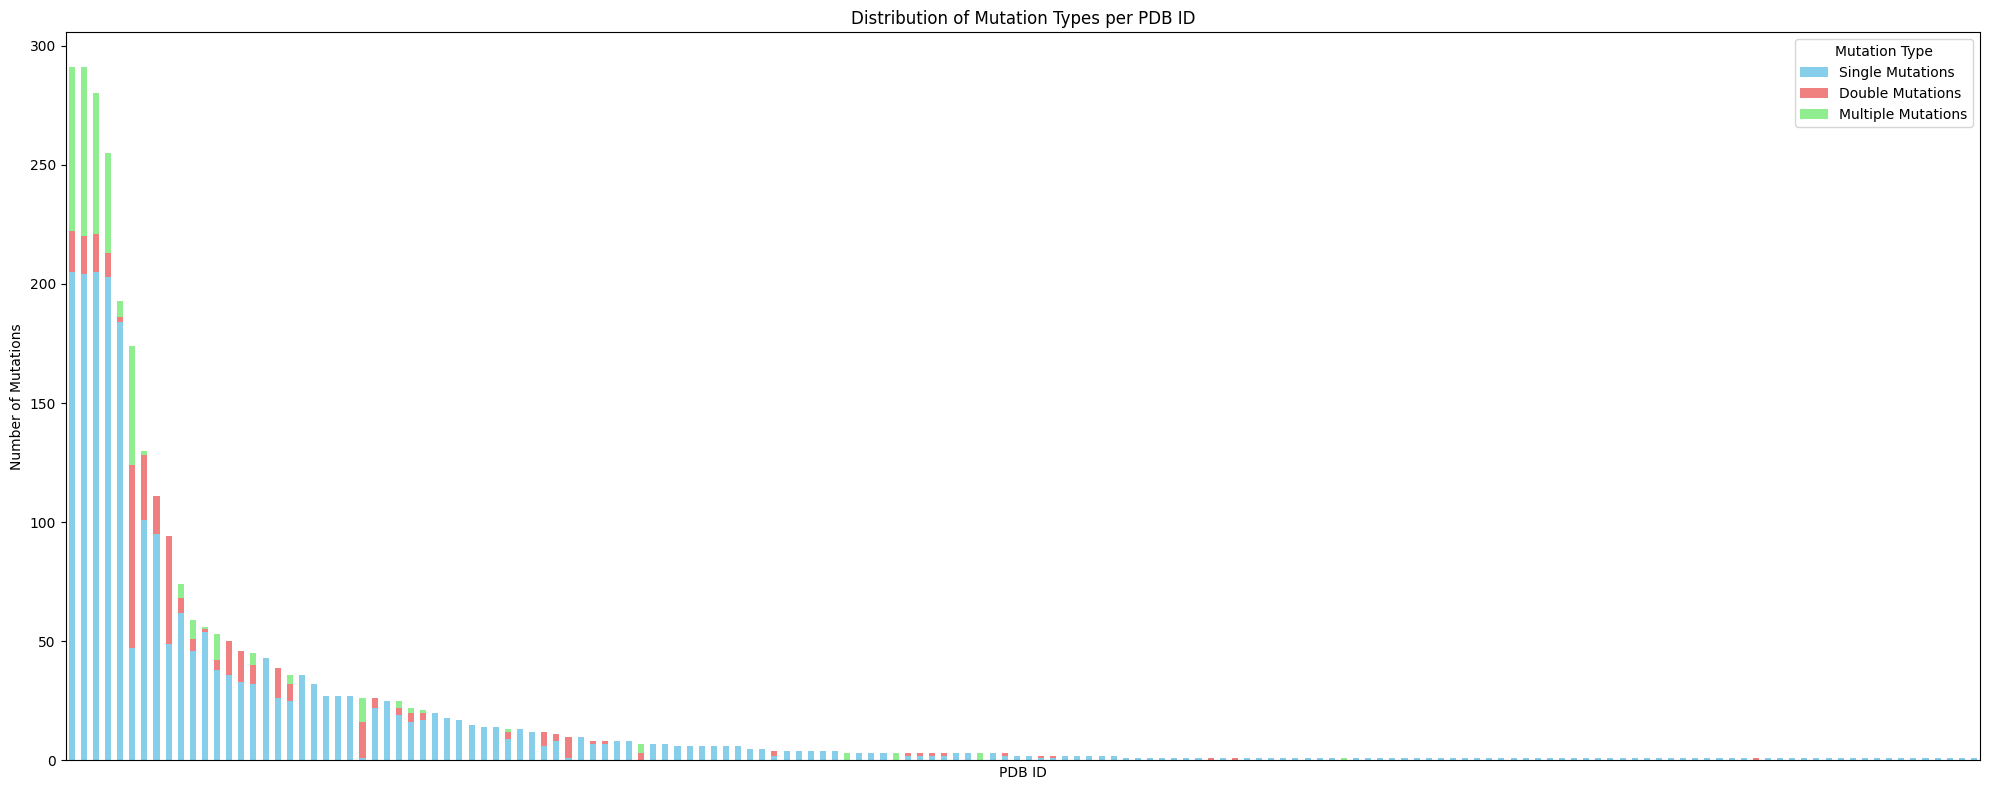

In [35]:
plot_data = []
for pdb_id, counts_list in mut_dist.items():
    s_count, d_count, m_count = counts_list[0]
    plot_data.append({'PDB': pdb_id, 'Single Mutations': s_count, 'Double Mutations': d_count, 'Multiple Mutations': m_count})

df_mutations = pd.DataFrame(plot_data)

# Sort by total mutations for better visualization, or by a specific type if preferred
df_mutations['Total Mutations'] = df_mutations['Single Mutations'] + df_mutations['Double Mutations'] + df_mutations['Multiple Mutations']
df_mutations = df_mutations.sort_values(by='Total Mutations', ascending=False)

# Plotting a stacked bar chart
plt.figure(figsize=(20, 8)) # Adjust figure size for better readability
df_mutations[['Single Mutations', 'Double Mutations', 'Multiple Mutations']].plot(kind='bar', stacked=True, figsize=(20, 8), color=['skyblue', 'lightcoral', 'lightgreen'])

plt.title('Distribution of Mutation Types per PDB ID')
plt.xlabel('PDB ID')
plt.ylabel('Number of Mutations')
plt.xticks([]) # Remove x-axis labels
plt.legend(title='Mutation Type')
plt.tight_layout()
plt.show()

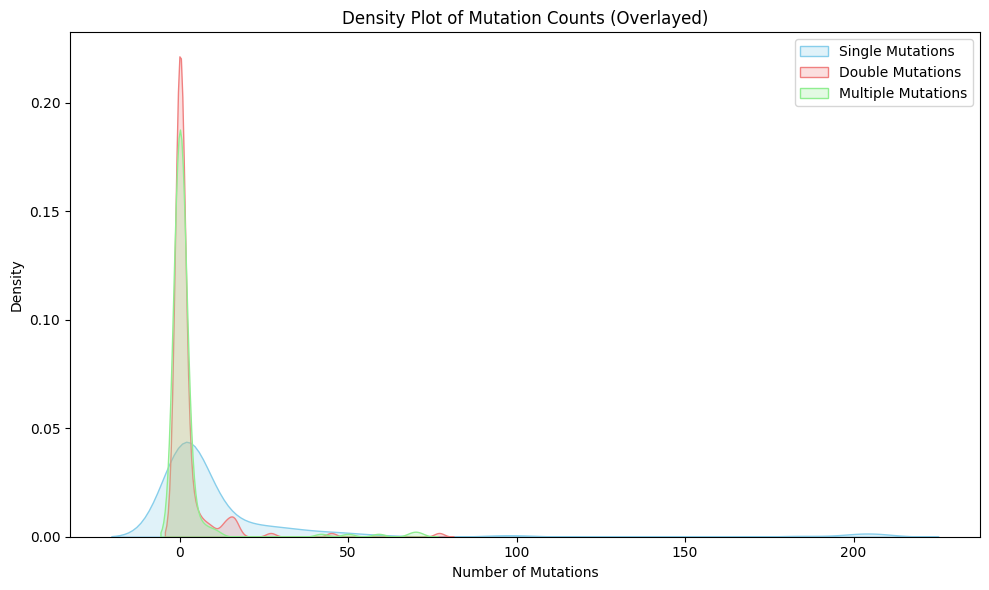

In [36]:
single_mut_counts = df_mutations['Single Mutations']
double_mut_counts = df_mutations['Double Mutations']
multiple_mut_counts = df_mutations['Multiple Mutations']

plt.figure(figsize=(10, 6))
sns.kdeplot(single_mut_counts, fill=True, color='skyblue', label='Single Mutations', bw_adjust=0.5)
sns.kdeplot(double_mut_counts, fill=True, color='lightcoral', label='Double Mutations', bw_adjust=0.5)
sns.kdeplot(multiple_mut_counts, fill=True, color='lightgreen', label='Multiple Mutations', bw_adjust=0.5)

plt.title('Density Plot of Mutation Counts (Overlayed)')
plt.xlabel('Number of Mutations')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 2000x800 with 0 Axes>

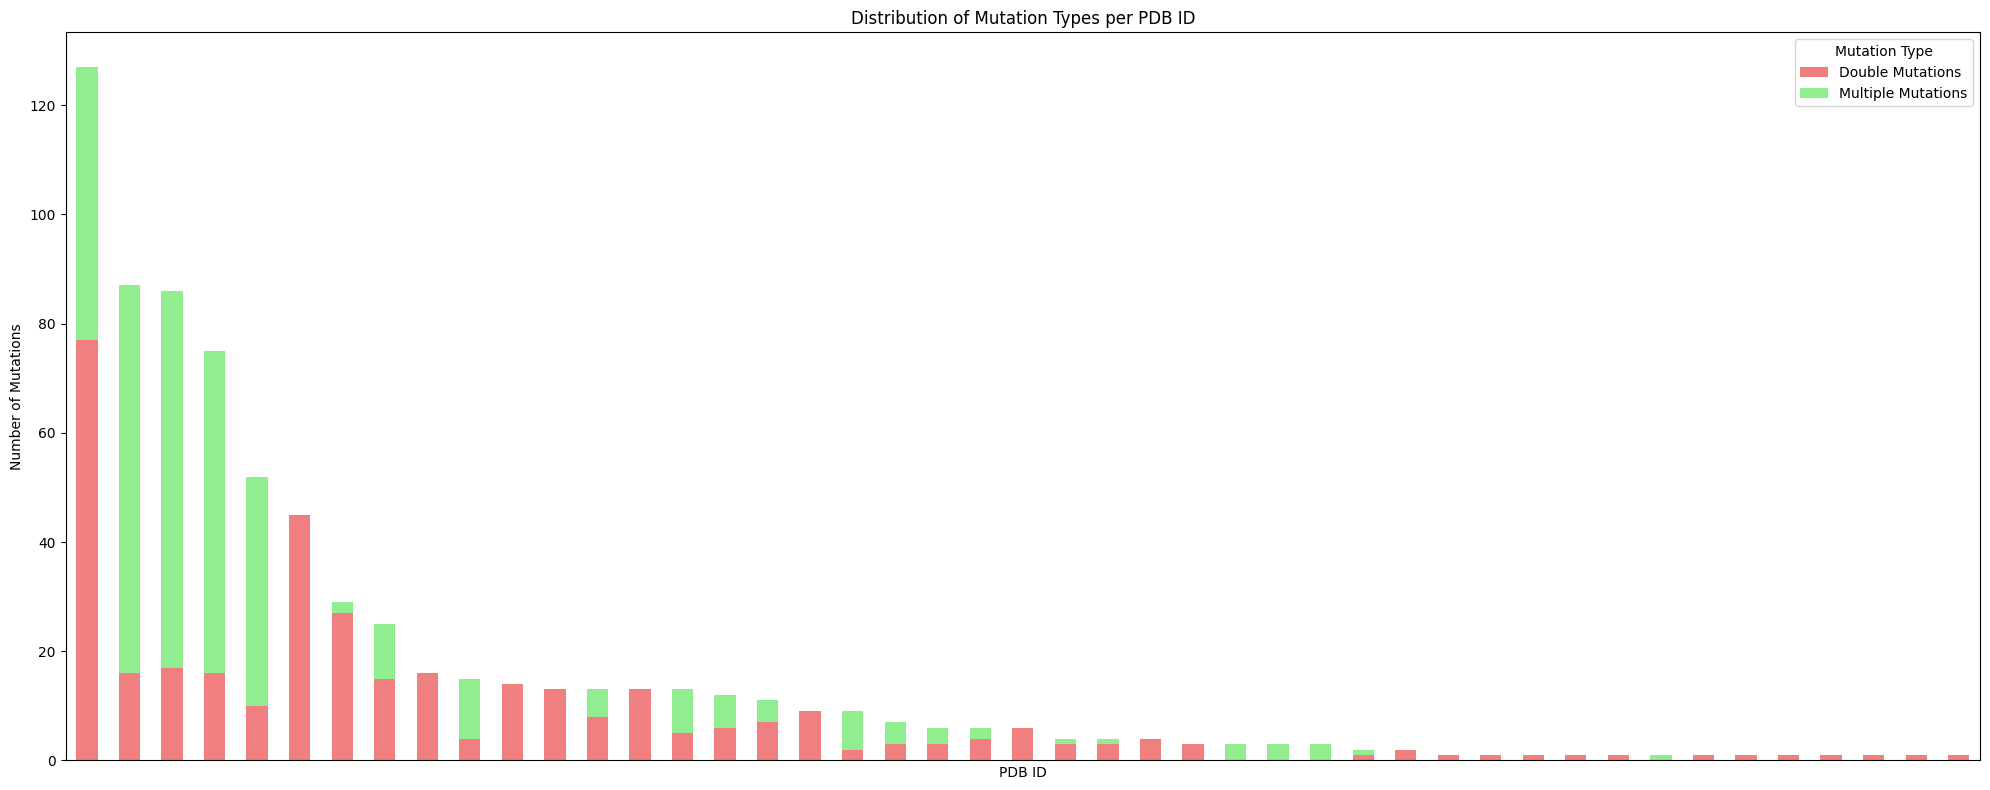

In [37]:
plot_data = []
for pdb_id, counts_list in mut_dist.items():
    _, d_count, m_count = counts_list[0]
    plot_data.append({'PDB': pdb_id, 'Double Mutations': d_count, 'Multiple Mutations': m_count})

df_mutations = pd.DataFrame(plot_data)

# Sort by total mutations for better visualization, or by a specific type if preferred
df_mutations['Total Mutations'] = df_mutations['Double Mutations'] + df_mutations['Multiple Mutations']

# Filter out PDB IDs where both Double and Multiple Mutations are zero
df_mutations = df_mutations[df_mutations['Total Mutations'] != 0]

df_mutations = df_mutations.sort_values(by='Total Mutations', ascending=False)

# Plotting a stacked bar chart
plt.figure(figsize=(20, 8)) # Adjust figure size for better readability
df_mutations[['Double Mutations', 'Multiple Mutations']].plot(kind='bar', stacked=True, figsize=(20, 8), color=[ 'lightcoral', 'lightgreen'])

plt.title('Distribution of Mutation Types per PDB ID')
plt.xlabel('PDB ID')
plt.ylabel('Number of Mutations')
plt.xticks([]) # Remove x-axis labels
plt.legend(title='Mutation Type')
plt.tight_layout()
plt.show()

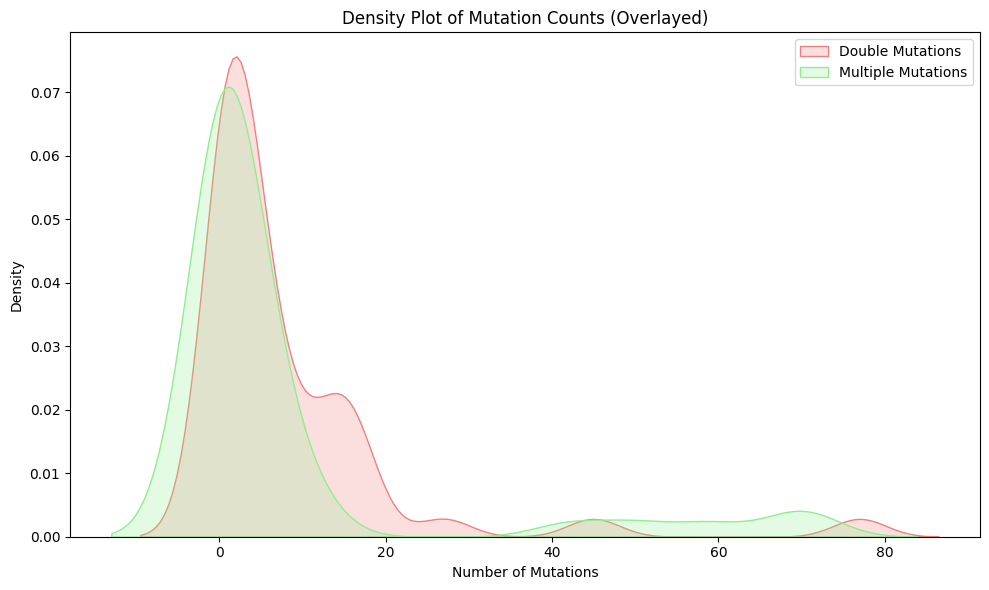

In [38]:
double_mut_counts = df_mutations['Double Mutations']
multiple_mut_counts = df_mutations['Multiple Mutations']

plt.figure(figsize=(10, 6))
sns.kdeplot(double_mut_counts, fill=True, color='lightcoral', label='Double Mutations', bw_adjust=0.5)
sns.kdeplot(multiple_mut_counts, fill=True, color='lightgreen', label='Multiple Mutations', bw_adjust=0.5)

plt.title('Density Plot of Mutation Counts (Overlayed)')
plt.xlabel('Number of Mutations')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()